In [1]:
import jax

from examples.train_and_log import *

Devices: [CpuDevice(id=0)]


## Environment and Agent

In [2]:
# Experiment
experiment_config = get_experiment_config()
experiment_name, checkpoint_path = create_experiment(checkpoint=False)
experiment_config["EXPERIMENT_NAME"] = experiment_name

# Environment
env_name = experiment_config["ENV_NAME"]
env_setting = experiment_config["ENV_SETTING"]
env_kwargs = experiment_config["ENV_KWARGS"]
env, eval_env = get_envs(env_name, env_setting, env_kwargs)

# Agent
algorithm = experiment_config["ALGORITHM"]
agent_class = jax_imprl.agents.get_agent_class(algorithm)
agent_config = get_agent_configs(algorithm)[env_name]
agent = agent_class(
    env,
    agent_config,
    experiment_config,
    eval_env=eval_env,
    checkpoint_path=checkpoint_path,
)

# Seeds
seed = experiment_config["SEED"]
num_runs = experiment_config["NUM_RUNS"]
key = jax.random.PRNGKey(seed)
subkeys = jax.random.split(key, num_runs)

/Users/pbhustali/miniforge3/envs/jax_imprl_env/lib/python3.9/site-packages/flashbax/buffers/trajectory_buffer.py:473: UserWarning: Setting max_size dynamically sets the `max_length_time_axis` to be `max_size`//`add_batch_size = 10000`.This allows one to control exactly how many timesteps are stored in the buffer.Note that this overrides the `max_length_time_axis` argument.
  warnings.warn(


## Training

In [ ]:
runner, metrics = jax.block_until_ready(agent.train(subkeys))

## Post-Procesing

Best: [55.61309]


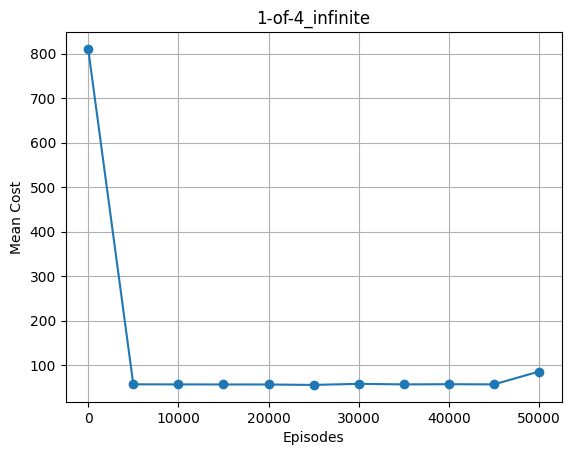

In [4]:
plot_results(experiment_config, metrics)

## WandB Logging

In [5]:
# log_to_wandb(experiment_config, agent_config, metrics)